In [1]:
# CELL 1 — Mount Drive and define all paths
# NB4 loads from Drive:
#   - Best model checkpoint from NB2
#   - split_indices.npz, cifar10h-probs.npy, entropies.npy from NB1
#   - Inference predictions saved by NB3

from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT         = '/content/drive/MyDrive/cifar10h_project'
DATA_DIR        = os.path.join(PROJECT, 'data')
CHECKPOINTS_DIR = os.path.join(PROJECT, 'checkpoints')
RESULTS_DIR     = os.path.join(PROJECT, 'results')
CIFAR10_DIR     = os.path.join(DATA_DIR, 'cifar10')
INFERENCE_DIR   = os.path.join(RESULTS_DIR, 'inference')

EXPLAIN_DIR     = os.path.join(RESULTS_DIR, 'explainability')
os.makedirs(EXPLAIN_DIR, exist_ok=True)

BEST_CKPT       = os.path.join(CHECKPOINTS_DIR, 'custom_best.pth')

# Files from NB1
CIFAR10H_PATH   = os.path.join(DATA_DIR, 'cifar10h-probs.npy')
SPLIT_PATH      = os.path.join(DATA_DIR, 'split_indices.npz')
ENTROPY_PATH    = os.path.join(DATA_DIR, 'entropies.npy')

# Predictions saved by NB3 — we are reusing these
PREDS_CUSTOM    = os.path.join(INFERENCE_DIR, 'preds_custom.npy')

print("Checking required files...")
required = {
    "Best checkpoint (NB2)"    : BEST_CKPT,
    "Soft labels (NB1)"        : CIFAR10H_PATH,
    "Split indices (NB1)"      : SPLIT_PATH,
    "Entropies (NB1)"          : ENTROPY_PATH,
    "Custom predictions (NB3)" : PREDS_CUSTOM,
}
all_ok = True
for name, path in required.items():
    exists = os.path.exists(path)
    print(f"  {'OK' if exists else 'MISSING':<8} {name}")
    if not exists:
        all_ok = False

if all_ok:
    print("\nAll files found. Ready to proceed.")
else:
    print("\nSome files missing. Check NB1, NB2, NB3 completed fully.")

Mounted at /content/drive
Checking required files...
  OK       Best checkpoint (NB2)
  OK       Soft labels (NB1)
  OK       Split indices (NB1)
  OK       Entropies (NB1)
  OK       Custom predictions (NB3)

All files found. Ready to proceed.


In [2]:
# CELL 2 — All imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader

import cv2
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

CLASS_NAMES  = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck']
EPSILON      = 1e-10
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

print("All imports successful.")

Device : cpu
All imports successful.


In [3]:
# CELL 3 — Rebuild model and dataset, load all data

#  Model
class ResNet18CIFAR(nn.Module):
    def __init__(self):
        super(ResNet18CIFAR, self).__init__()
        self.backbone         = models.resnet18(weights=None)
        self.backbone.conv1   = nn.Conv2d(3, 64, kernel_size=3,
                                          stride=1, padding=1, bias=False)
        self.backbone.maxpool = nn.Identity()
        self.backbone.fc      = nn.Linear(
            self.backbone.fc.in_features, 10
        )

    def forward(self, x):
        logits = self.backbone(x)
        return F.softmax(logits, dim=1)


#  Dataset
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

class CIFAR10HDataset(Dataset):
    def __init__(self, indices, soft_labels, transform=None):
        self.cifar10_test = torchvision.datasets.CIFAR10(
            root=CIFAR10_DIR, train=False,
            download=False, transform=None
        )
        self.indices     = indices
        self.soft_labels = soft_labels
        self.transform   = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        actual_idx            = self.indices[i]
        pil_image, hard_label = self.cifar10_test[actual_idx]
        if self.transform:
            image = self.transform(pil_image)
        else:
            image = transforms.ToTensor()(pil_image)
        soft_label = torch.tensor(
            self.soft_labels[actual_idx], dtype=torch.float32
        )
        return image, soft_label, hard_label, actual_idx


#  Load model
model = ResNet18CIFAR().to(DEVICE)
checkpoint = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Loaded checkpoint: {checkpoint['loss_name']} model  "
      f"(val_loss={checkpoint['val_loss']:.5f})")

#  Load data
soft_labels  = np.load(CIFAR10H_PATH).astype(np.float32)
split_data   = np.load(SPLIT_PATH)
test_indices = split_data['test_indices']
entropies    = np.load(ENTROPY_PATH)

true_soft    = soft_labels[test_indices]
true_entropy = entropies[test_indices]

# Load predictions saved by NB3
preds = np.load(PREDS_CUSTOM)

pred_entropy = -(preds * np.log2(
    np.clip(preds, EPSILON, 1.0)
)).sum(axis=1)

raw_test = torchvision.datasets.CIFAR10(
    root=CIFAR10_DIR, train=False,
    download=False,
    transform=transforms.ToTensor()
)

print(f"\nData loaded:")
print(f"  Test images    : {len(test_indices)}")
print(f"  True entropy   : [{true_entropy.min():.3f}, "
      f"{true_entropy.max():.3f}] bits")
print(f"  Predicted entropy: [{pred_entropy.min():.3f}, "
      f"{pred_entropy.max():.3f}] bits")

Loaded checkpoint: custom model  (val_loss=0.17646)

Data loaded:
  Test images    : 2000
  True entropy   : [0.000, 2.860] bits
  Predicted entropy: [0.000, 2.710] bits


In [4]:
# CELL 4 — Grad-CAM implementation
# Grad-CAM (Gradient-weighted Class Activation Mapping)
# highlights which regions of an image most influenced
# the model's prediction.
#
# How it works:
#   1. Run a forward pass — save the feature maps from the
#      last convolutional layer
#   2. Run a backward pass on the target class score
#      — compute gradients of that score w.r.t. the feature maps
#   3. Average the gradients spatially → importance weights
#   4. Weighted sum of feature maps → heatmap
#   5. ReLU to keep only positive influence
#   6. Resize heatmap to match input image size (32×32)
#
# For this project we use the HIGHEST PROBABILITY CLASS
# as the target — we want to see what the model focused on
# when making its top prediction.
#
# We use hooks — these are PyTorch callbacks that run
# automatically during forward/backward and capture
# intermediate values we need.

class GradCAM:
    """
    Grad-CAM for ResNet18CIFAR.
    Hooks into the last convolutional layer (layer4).
    """

    def __init__(self, model):
        self.model       = model
        self.gradients   = None   # will store gradients
        self.activations = None   # will store feature maps


        target_layer = model.backbone.layer4[-1].conv2

        def save_activation(module, input, output):
            self.activations = output.detach()


        def save_gradient(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        target_layer.register_forward_hook(save_activation)
        target_layer.register_backward_hook(save_gradient)

    def generate(self, image_tensor, target_class=None):
        """
        Generate Grad-CAM heatmap for one image.

        image_tensor : (1, 3, 32, 32) normalised tensor on DEVICE
        target_class : which class to explain. If None, uses argmax.

        Returns:
            heatmap      : (32, 32) numpy array, values in [0, 1]
            target_class : int — which class was explained
            probs        : (10,) numpy array — full predicted distribution
        """
        self.model.eval()
        image_tensor = image_tensor.to(DEVICE)
        image_tensor.requires_grad_(True)

        probs = self.model(image_tensor)

        if target_class is None:
            target_class = probs.argmax(dim=1).item()

        self.model.zero_grad()

        score = probs[0, target_class]
        score.backward()
        weights = self.gradients.mean(dim=(2, 3))

        cam = (weights[:, :, None, None] * self.activations).sum(dim=1)
        cam = F.relu(cam).squeeze(0).cpu().numpy()
        cam = cv2.resize(cam, (32, 32))
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam, target_class, probs.detach().cpu().numpy()[0]


# Instantiate GradCAM with the loaded model
gradcam = GradCAM(model)
print("GradCAM ready.")
print("Target layer: model.backbone.layer4[-1].conv2")

GradCAM ready.
Target layer: model.backbone.layer4[-1].conv2


In [5]:
# CELL 5 — Helper function to plot one Grad-CAM result

def plot_gradcam_row(axes_row, actual_idx, local_idx,
                     true_ent_val, pred_ent_val, label):
    """
    Plots one row of the Grad-CAM figure:
      col 0: original image
      col 1: Grad-CAM heatmap overlay
      col 2: true human distribution
      col 3: predicted distribution

    axes_row    : list of 4 matplotlib axes
    actual_idx  : index into the full 10k test set
    local_idx   : index into the 2000 test split
    """
    raw_img, hard_lbl = raw_test[actual_idx]
    img_np = np.transpose(raw_img.numpy(), (1, 2, 0))  # (32,32,3)

    norm_img = eval_transform(
        torchvision.datasets.CIFAR10(
            root=CIFAR10_DIR, train=False,
            download=False, transform=None
        )[actual_idx][0]
    ).unsqueeze(0)

    heatmap, target_cls, probs = gradcam.generate(norm_img)

    axes_row[0].imshow(img_np)
    axes_row[0].axis('off')
    axes_row[0].set_title(
        f'{label}\n{CLASS_NAMES[hard_lbl]}\n'
        f'H_true={true_ent_val:.2f}  H_pred={pred_ent_val:.2f}',
        fontsize=7
    )

    #  Col 1: Grad-CAM overlay
    # Apply colormap to heatmap, original image with labels (true entropy, predicted entropy, hard lanel)
    heatmap_colored = cv2.applyColorMap(
        (heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET
    )
    heatmap_rgb = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    heatmap_rgb = heatmap_rgb.astype(np.float32) / 255.0

    # Blend: 60% original image + 40% heatmap
    overlay = 0.6 * img_np + 0.4 * heatmap_rgb
    overlay = np.clip(overlay, 0, 1)
    axes_row[1].imshow(overlay)
    axes_row[1].axis('off')
    axes_row[1].set_title(f'Grad-CAM\n→ {CLASS_NAMES[target_cls]}',
                           fontsize=7)

    #  Col 2: True distribution
    # Grad-CAM heatmap overlaid on the image- shows what the modelfocused on
    true_dist = true_soft[local_idx]
    colors_true = ['#d32f2f' if v == true_dist.max()
                   else '#90caf9' for v in true_dist]
    axes_row[2].bar(range(10), true_dist,
                    color=colors_true, edgecolor='white', linewidth=0.3)
    axes_row[2].set_ylim(0, 1.05)
    axes_row[2].set_xticks(range(10))
    axes_row[2].set_xticklabels(
        [c[:3] for c in CLASS_NAMES], rotation=90, fontsize=5
    )
    axes_row[2].set_yticks([0, 0.5, 1.0])
    axes_row[2].tick_params(labelsize=5)
    axes_row[2].set_title('True dist', fontsize=7)

    #  Col 3: Predicted distribution
    #Bar chart of the true human distribution from 10H dataset
    pred_dist  = preds[local_idx]
    colors_pred = ['#e65100' if v == pred_dist.max()
                   else '#ffcc80' for v in pred_dist]
    axes_row[3].bar(range(10), pred_dist,
                    color=colors_pred, edgecolor='white', linewidth=0.3)
    axes_row[3].set_ylim(0, 1.05)
    axes_row[3].set_xticks(range(10))
    axes_row[3].set_xticklabels(
        [c[:3] for c in CLASS_NAMES], rotation=90, fontsize=5
    )
    axes_row[3].set_yticks([0, 0.5, 1.0])
    axes_row[3].tick_params(labelsize=5)
    axes_row[3].set_title('Predicted dist', fontsize=7)


print("Grad-CAM plot helper defined.")

Grad-CAM plot helper defined.


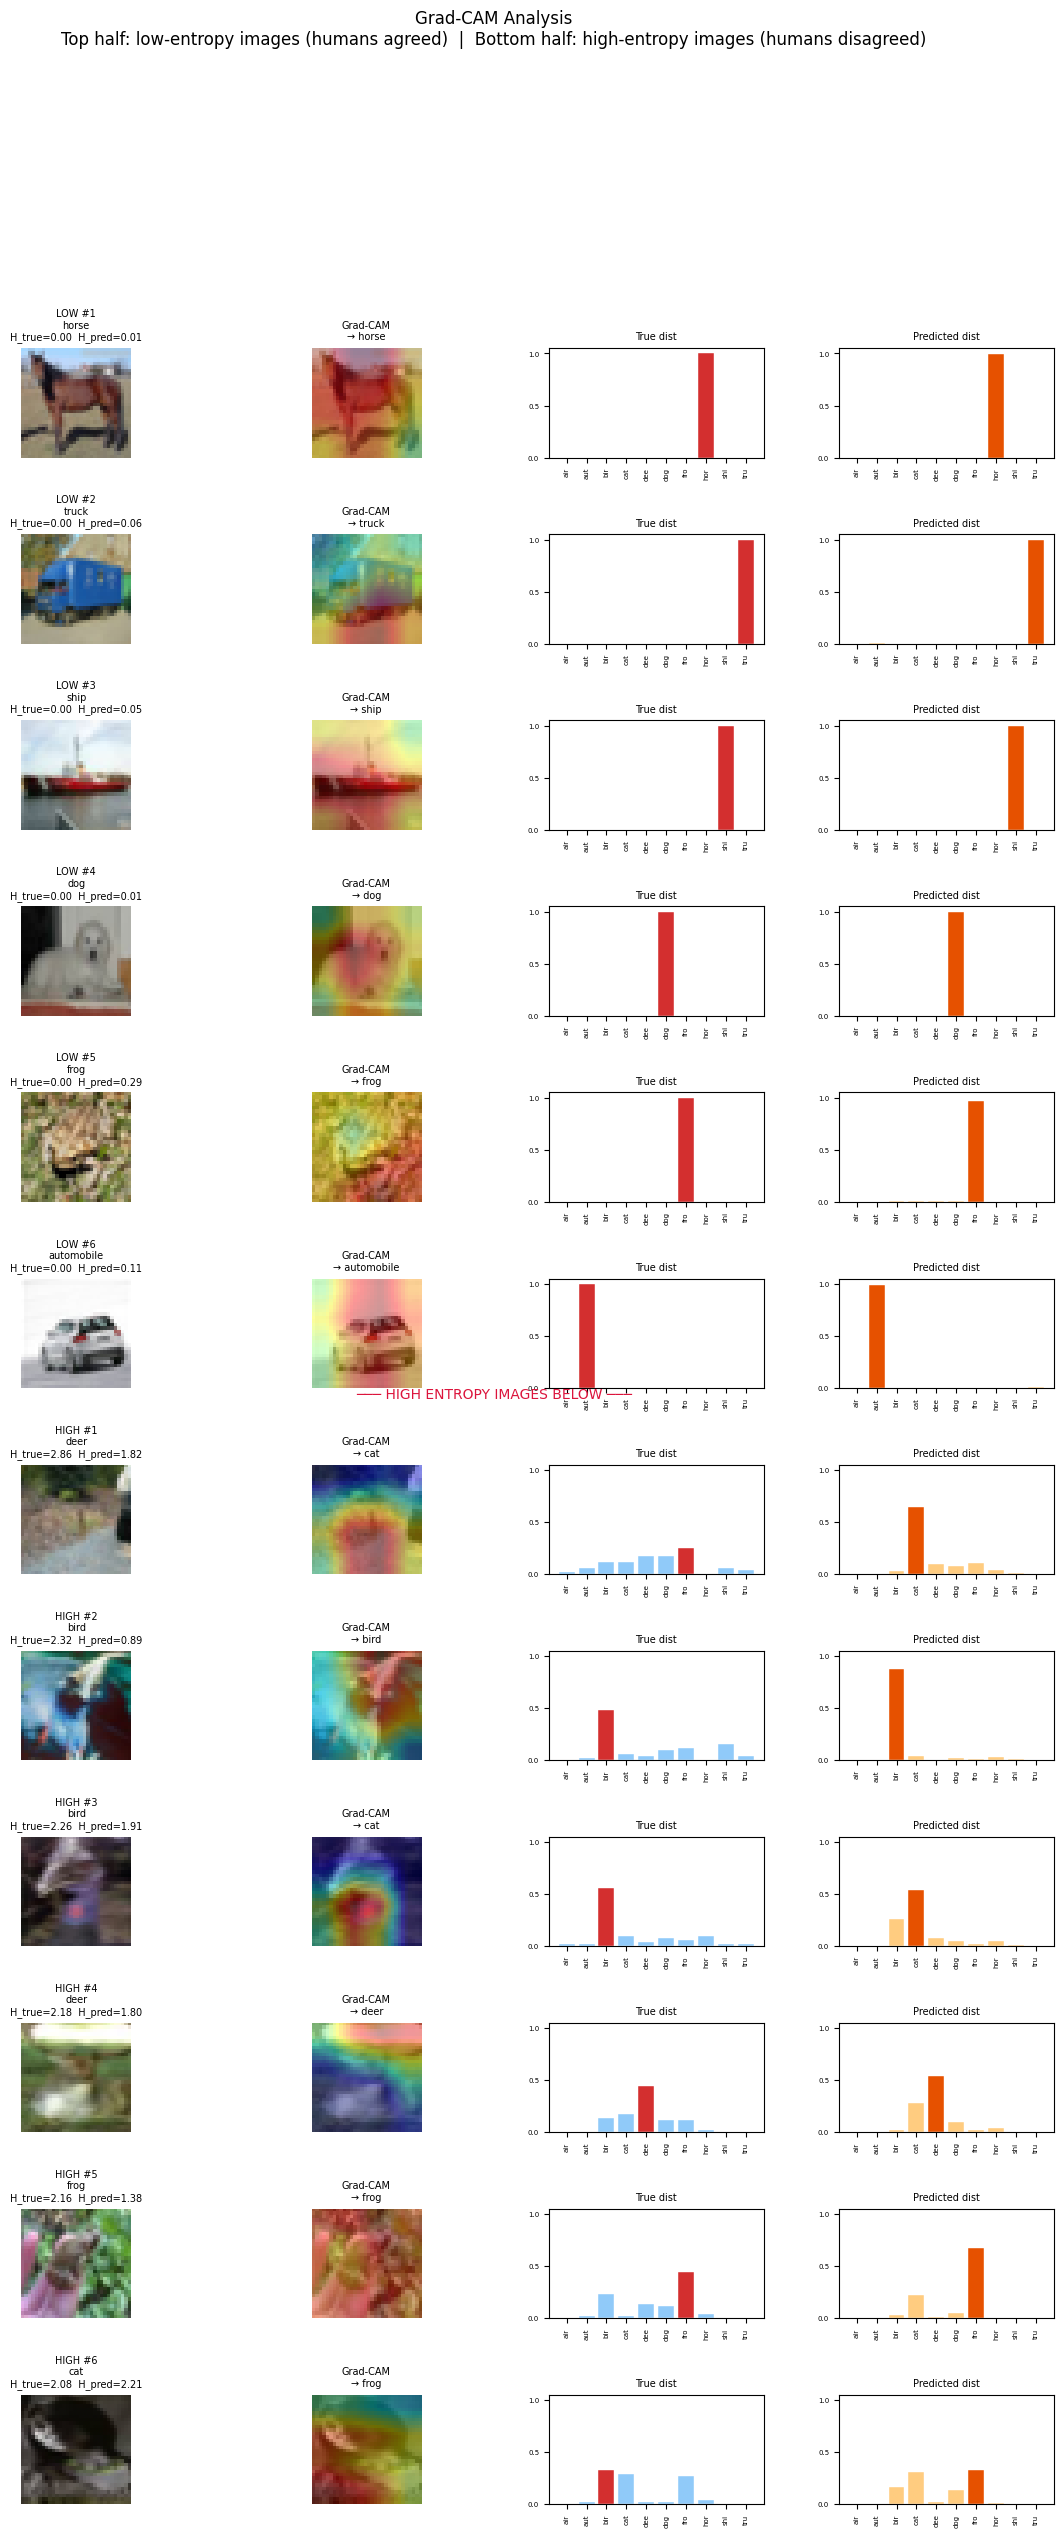

Saved to: /content/drive/MyDrive/cifar10h_project/results/explainability/gradcam_low_vs_high_entropy.png


In [6]:
# CELL 6 — Grad-CAM: low entropy vs high entropy images
N_EXAMPLES    = 6
sorted_by_ent = np.argsort(true_entropy)

low_local_idx  = sorted_by_ent[:N_EXAMPLES]
high_local_idx = sorted_by_ent[-N_EXAMPLES:][::-1]

fig = plt.figure(figsize=(14, 28))
fig.suptitle(
    'Grad-CAM Analysis\n'
    'Top half: low-entropy images (humans agreed)  |  '
    'Bottom half: high-entropy images (humans disagreed)',
    fontsize=12, y=1.001
)

gs = gridspec.GridSpec(12, 4, figure=fig, hspace=0.7, wspace=0.35)

#  Low entropy rows
for row, local_idx in enumerate(low_local_idx):
    actual_idx = test_indices[local_idx]
    axes_row   = [fig.add_subplot(gs[row, col]) for col in range(4)]
    plot_gradcam_row(
        axes_row, actual_idx, local_idx,
        true_entropy[local_idx], pred_entropy[local_idx],
        label=f'LOW #{row+1}'
    )

# Section divider text
fig.text(0.5, 0.505,
         '─── HIGH ENTROPY IMAGES BELOW ───',
         ha='center', fontsize=10, color='crimson')

#  High entropy rows
for row, local_idx in enumerate(high_local_idx):
    actual_idx = test_indices[local_idx]
    axes_row   = [fig.add_subplot(gs[row + 6, col]) for col in range(4)]
    plot_gradcam_row(
        axes_row, actual_idx, local_idx,
        true_entropy[local_idx], pred_entropy[local_idx],
        label=f'HIGH #{row+1}'
    )

plt.tight_layout()
save_path = os.path.join(EXPLAIN_DIR, 'gradcam_low_vs_high_entropy.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")


Top 6 Type A failures (model overestimated ambiguity):
  #1  true_H=0.137  pred_H=2.646  error=+2.509  class=frog
  #2  true_H=0.000  pred_H=2.441  error=+2.441  class=horse
  #3  true_H=0.139  pred_H=2.548  error=+2.409  class=bird
  #4  true_H=0.000  pred_H=2.397  error=+2.397  class=deer
  #5  true_H=0.137  pred_H=2.483  error=+2.346  class=automobile
  #6  true_H=0.000  pred_H=2.329  error=+2.329  class=airplane

Top 6 Type B failures (model underestimated ambiguity):
  #1  true_H=1.905  pred_H=0.321  error=-1.584  class=bird
  #2  true_H=1.645  pred_H=0.069  error=-1.577  class=bird
  #3  true_H=2.316  pred_H=0.885  error=-1.431  class=bird
  #4  true_H=1.688  pred_H=0.370  error=-1.318  class=airplane
  #5  true_H=1.454  pred_H=0.141  error=-1.312  class=airplane
  #6  true_H=1.162  pred_H=0.100  error=-1.062  class=dog


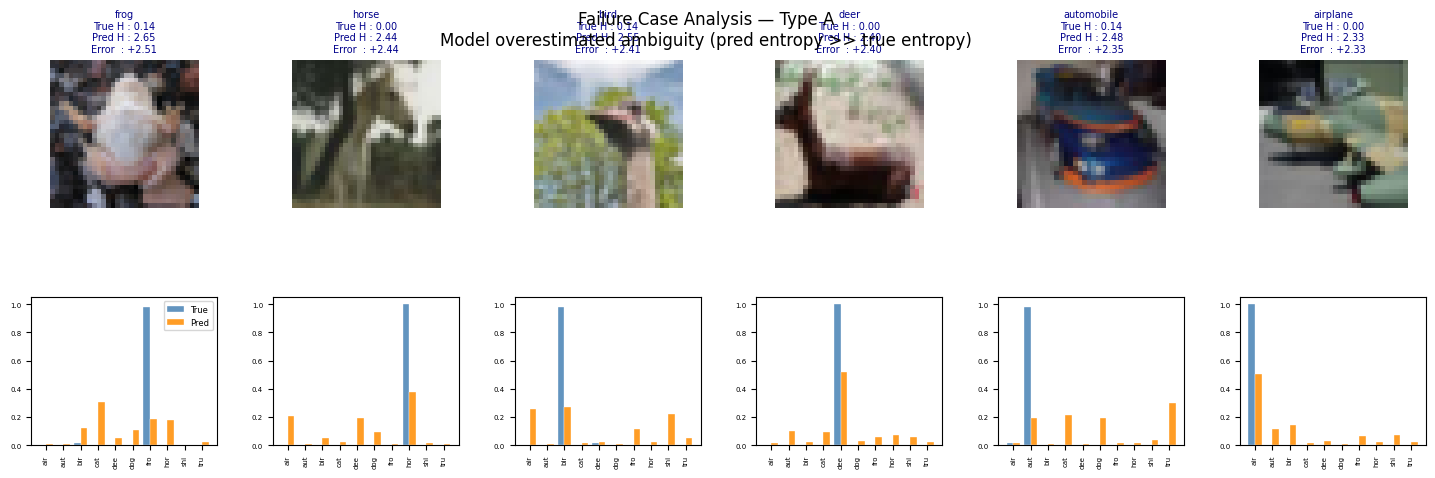

Saved to: /content/drive/MyDrive/cifar10h_project/results/explainability/failure_cases_type_A.png


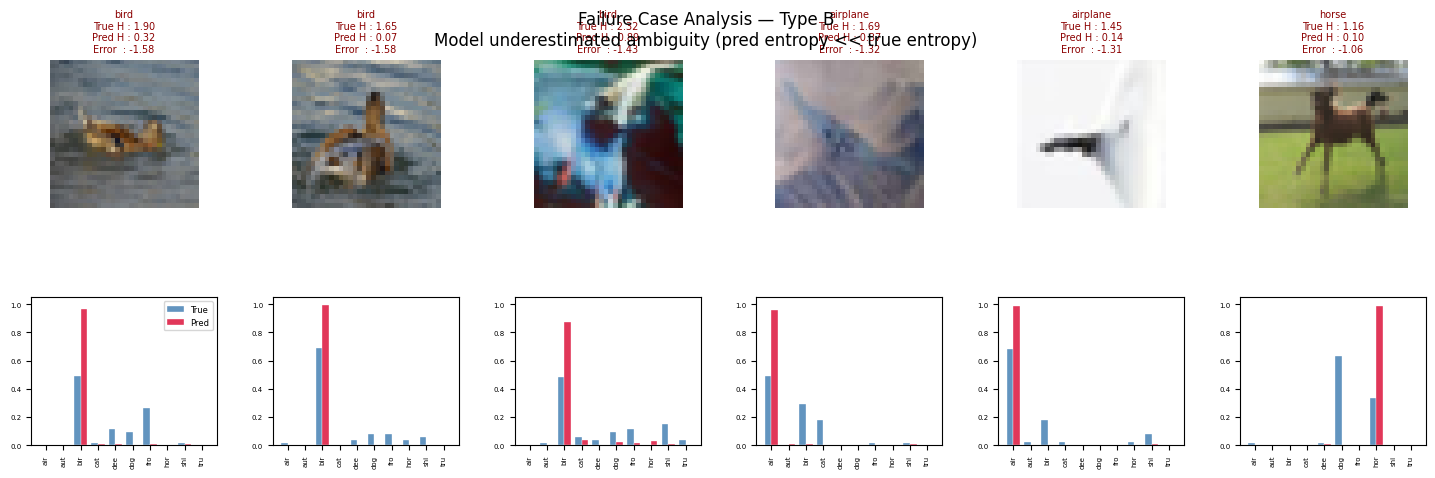

Saved to: /content/drive/MyDrive/cifar10h_project/results/explainability/failure_cases_type_B.png


In [7]:
# CELL 7 — Failure Case Analysis (compulsory)
# Two types of failure:
#   Type A — FALSE ALARM: model predicted HIGH entropy
#             but true entropy was LOW (overestimates ambiguity)
#             Model thought: "this is confusing"
#             Humans actually: "this is obvious"
#
#   Type B — MISSED: model predicted LOW entropy
#             but true entropy was HIGH (underestimates ambiguity)
#             Model thought: "this is obvious"
#             Humans actually: "this is confusing"

entropy_error = pred_entropy - true_entropy
# Positive error = model overestimated ambiguity (Type A)
# Negative error = model underestimated ambiguity (Type B)

type_a_idx = np.argsort(entropy_error)[-6:][::-1]
type_b_idx = np.argsort(entropy_error)[:6]

print("Top 6 Type A failures (model overestimated ambiguity):")
for i, idx in enumerate(type_a_idx):
    print(f"  #{i+1}  true_H={true_entropy[idx]:.3f}  "
          f"pred_H={pred_entropy[idx]:.3f}  "
          f"error={entropy_error[idx]:+.3f}  "
          f"class={CLASS_NAMES[np.argmax(true_soft[idx])]}")

print("\nTop 6 Type B failures (model underestimated ambiguity):")
for i, idx in enumerate(type_b_idx):
    print(f"  #{i+1}  true_H={true_entropy[idx]:.3f}  "
          f"pred_H={pred_entropy[idx]:.3f}  "
          f"error={entropy_error[idx]:+.3f}  "
          f"class={CLASS_NAMES[np.argmax(true_soft[idx])]}")


def plot_failure_cases(local_indices, failure_type, color):
    """
    Plots a row of failure cases.
    Each case: image | true dist | pred dist | error annotation
    """
    n    = len(local_indices)
    fig  = plt.figure(figsize=(18, 5))
    fig.suptitle(
        f'Failure Case Analysis — Type {failure_type}\n'
        f'{"Model overestimated ambiguity (pred entropy >> true entropy)" if failure_type == "A" else "Model underestimated ambiguity (pred entropy << true entropy)"}',
        fontsize=12
    )
    gs = gridspec.GridSpec(2, n, figure=fig, hspace=0.6, wspace=0.3)

    for col, local_idx in enumerate(local_indices):
        actual_idx     = test_indices[local_idx]
        raw_img, hard_lbl = raw_test[actual_idx]
        img_np         = np.transpose(raw_img.numpy(), (1, 2, 0))

        ax_img = fig.add_subplot(gs[0, col])
        ax_img.imshow(img_np)
        ax_img.axis('off')
        ax_img.set_title(
            f'{CLASS_NAMES[hard_lbl]}\n'
            f'True H : {true_entropy[local_idx]:.2f}\n'
            f'Pred H : {pred_entropy[local_idx]:.2f}\n'
            f'Error  : {entropy_error[local_idx]:+.2f}',
            fontsize=7,
            color='darkred' if failure_type == 'B' else 'darkblue'
        )

        ax_dist = fig.add_subplot(gs[1, col])
        x       = np.arange(10)
        width   = 0.38
        ax_dist.bar(x - width/2, true_soft[local_idx],
                    width, label='True', color='steelblue',
                    edgecolor='white', linewidth=0.3, alpha=0.85)
        ax_dist.bar(x + width/2, preds[local_idx],
                    width, label='Pred', color=color,
                    edgecolor='white', linewidth=0.3, alpha=0.85)
        ax_dist.set_ylim(0, 1.05)
        ax_dist.set_xticks(x)
        ax_dist.set_xticklabels(
            [c[:3] for c in CLASS_NAMES], rotation=90, fontsize=5
        )
        ax_dist.tick_params(labelsize=5)
        if col == 0:
            ax_dist.legend(fontsize=6)

    plt.tight_layout()
    save_path = os.path.join(
        EXPLAIN_DIR, f'failure_cases_type_{failure_type}.png'
    )
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to: {save_path}")


# Plot both failure types
plot_failure_cases(type_a_idx, 'A', color='darkorange')
plot_failure_cases(type_b_idx, 'B', color='crimson')

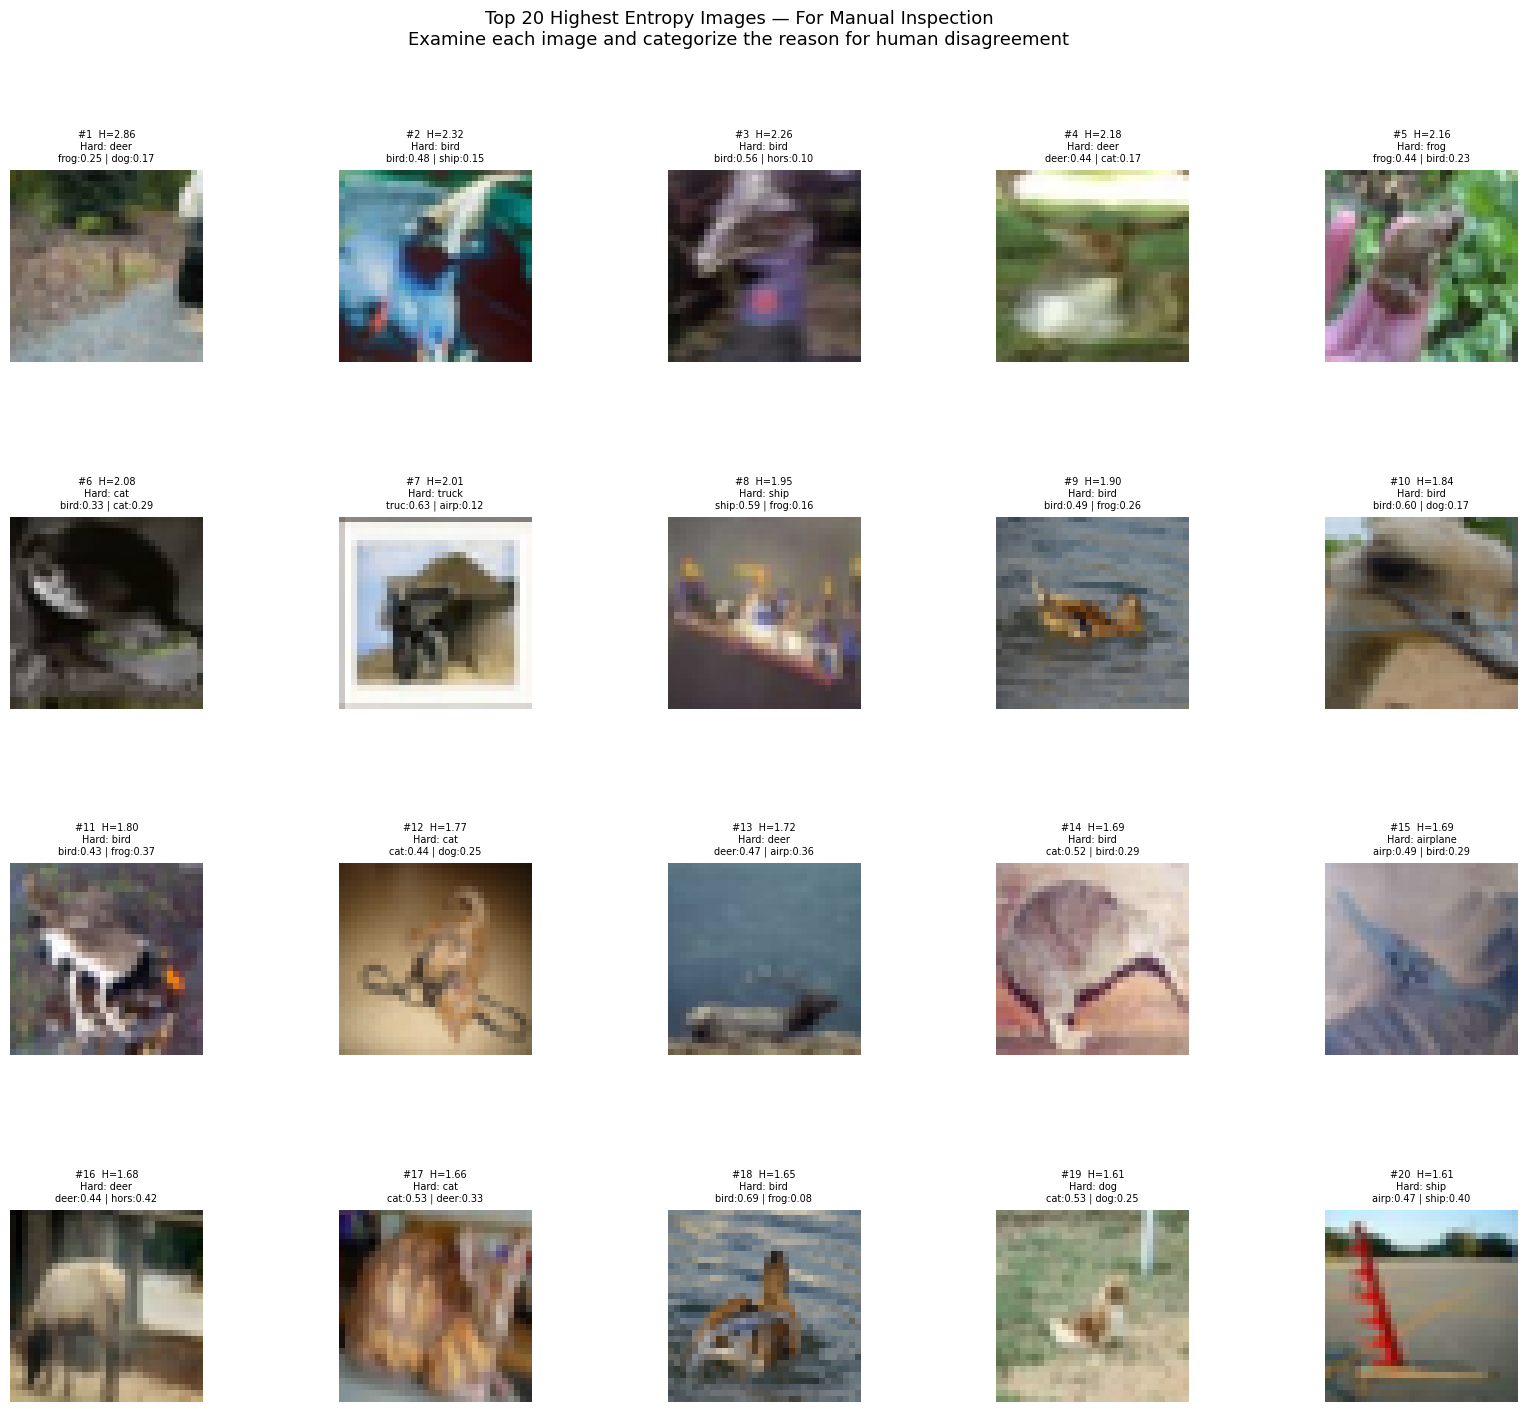

Saved to: /content/drive/MyDrive/cifar10h_project/results/explainability/manual_inspection_top20.png

MANUAL INSPECTION TABLE
Fill in the 'Category' column yourself after looking at each image
#    Class        H_true   Top 2 human votes                   Category
----------------------------------------------------------------------
1    deer         2.860    frog:0.25  dog:0.17                 [your label]
2    bird         2.316    bird:0.48  ship:0.15                [your label]
3    bird         2.261    bird:0.56  horse:0.10               [your label]
4    deer         2.177    deer:0.44  cat:0.17                 [your label]
5    frog         2.158    frog:0.44  bird:0.23                [your label]
6    cat          2.076    bird:0.33  cat:0.29                 [your label]
7    truck        2.005    truck:0.63  airplane:0.12           [your label]
8    ship         1.949    ship:0.59  frog:0.16                [your label]
9    bird         1.905    bird:0.49  frog:0.26         

In [8]:
# CELL 8 — Manual Disagreement Source Analysis (compulsory)
N_INSPECT     = 20
top_entropy_idx = np.argsort(true_entropy)[-N_INSPECT:][::-1]

# ── Plot grid of top-20 highest entropy images ────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle(
    f'Top {N_INSPECT} Highest Entropy Images — For Manual Inspection\n'
    'Examine each image and categorize the reason for human disagreement',
    fontsize=13
)

gs = gridspec.GridSpec(4, 5, figure=fig, hspace=0.8, wspace=0.4)

for i, local_idx in enumerate(top_entropy_idx):
    actual_idx        = test_indices[local_idx]
    raw_img, hard_lbl = raw_test[actual_idx]
    img_np            = np.transpose(raw_img.numpy(), (1, 2, 0))
    true_dist         = true_soft[local_idx]

    row = i // 5
    col = i %  5

    # Image subplot (top of each cell)
    ax = fig.add_subplot(gs[row, col])
    ax.imshow(img_np)
    ax.axis('off')

    # Find top 2 classes humans voted for
    top2_idx  = np.argsort(true_dist)[-2:][::-1]
    top2_str  = (f"{CLASS_NAMES[top2_idx[0]][:4]}:"
                 f"{true_dist[top2_idx[0]]:.2f} | "
                 f"{CLASS_NAMES[top2_idx[1]][:4]}:"
                 f"{true_dist[top2_idx[1]]:.2f}")

    ax.set_title(
        f'#{i+1}  H={true_entropy[local_idx]:.2f}\n'
        f'Hard: {CLASS_NAMES[hard_lbl]}\n'
        f'{top2_str}',
        fontsize=7
    )

plt.tight_layout()
save_path = os.path.join(EXPLAIN_DIR, 'manual_inspection_top20.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

# ── Print structured inspection table ────────────────────────
print("\n" + "=" * 70)
print("MANUAL INSPECTION TABLE")
print("Fill in the 'Category' column yourself after looking at each image")
print("=" * 70)
print(f"{'#':<4} {'Class':<12} {'H_true':<8} {'Top 2 human votes':<35} {'Category'}")
print("-" * 70)
for i, local_idx in enumerate(top_entropy_idx):
    actual_idx = test_indices[local_idx]
    _, hard_lbl = raw_test[actual_idx]
    true_dist   = true_soft[local_idx]
    top2_idx    = np.argsort(true_dist)[-2:][::-1]
    top2_str    = (f"{CLASS_NAMES[top2_idx[0]]}:{true_dist[top2_idx[0]]:.2f}  "
                   f"{CLASS_NAMES[top2_idx[1]]}:{true_dist[top2_idx[1]]:.2f}")
    print(f"{i+1:<4} {CLASS_NAMES[hard_lbl]:<12} "
          f"{true_entropy[local_idx]:<8.3f} {top2_str:<35} [your label]")
print("=" * 70)
print("\nCategories to use:")
print("  1 = Ambiguous object identity")
print("  2 = Poor image quality / blurry")
print("  3 = Multi-object content")
print("  4 = Boundary case between classes")
print("  5 = Other")

In [9]:
# CELL 9 — Robustness Check B: OOD Image Corruptions
# We apply three corruption types at increasing severity:
#   1. Gaussian noise  — adds random pixel-level noise
#   2. Gaussian blur   — blurs the image (simulates low resolution)
#   3. Contrast reduction — makes image look washed out
# We test on a subset of 200 images for speed.
# ============================================================

from torchvision.transforms import functional as TF
from PIL import Image, ImageFilter, ImageEnhance

N_CORRUPT     = 200
corrupt_idx   = np.linspace(0, len(test_indices)-1, N_CORRUPT,
                             dtype=int)

NOISE_STDS    = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]
BLUR_RADII    = [0.0, 0.5,  1.0,  1.5,  2.0,  3.0 ]
CONTRAST_VALS = [1.0, 0.8,  0.6,  0.4,  0.2,  0.1 ]
# Contrast: 1.0 = original, 0.0 = grey image


def predict_entropy_corrupted(local_indices, corrupt_fn, device):
    """
    Apply corrupt_fn to each image, run model, return mean predicted entropy.
    corrupt_fn : callable that takes a PIL image and returns a PIL image
    """
    model.eval()
    all_pred_ent = []

    with torch.no_grad():
        for local_idx in local_indices:
            actual_idx    = test_indices[local_idx]
            pil_img, _    = raw_test.dataset[actual_idx] \
                if hasattr(raw_test, 'dataset') \
                else torchvision.datasets.CIFAR10(
                    root=CIFAR10_DIR, train=False,
                    download=False, transform=None
                )[actual_idx]


            corrupted_pil = corrupt_fn(pil_img)

            img_tensor = eval_transform(corrupted_pil).unsqueeze(0).to(device)

            probs    = model(img_tensor).cpu().numpy()[0]
            ent      = -(probs * np.log2(np.clip(probs, EPSILON, 1.0))).sum()
            all_pred_ent.append(ent)

    return np.mean(all_pred_ent)


clean_dataset = torchvision.datasets.CIFAR10(
    root=CIFAR10_DIR, train=False, download=False, transform=None
)

print("Running corruption robustness checks...")
print("(200 images × 3 corruption types × 6 severities = 3600 forward passes)")
print("Estimated time: ~3-5 minutes\n")

results_noise    = []
results_blur     = []
results_contrast = []

#  Gaussian noise
print("1/3 Gaussian noise")
for std in NOISE_STDS:
    def noise_fn(pil_img, s=std):
        img_np    = np.array(pil_img).astype(np.float32) / 255.0
        noise     = np.random.normal(0, s, img_np.shape).astype(np.float32)
        corrupted = np.clip(img_np + noise, 0, 1)
        return Image.fromarray((corrupted * 255).astype(np.uint8))

    mean_ent = predict_entropy_corrupted(corrupt_idx, noise_fn, DEVICE)
    results_noise.append(mean_ent)
    print(f"  std={std:.2f}  mean predicted entropy: {mean_ent:.4f}")

#  Gaussian blur
print("\n2/3 Gaussian blur")
for radius in BLUR_RADII:
    def blur_fn(pil_img, r=radius):
        if r == 0:
            return pil_img
        return pil_img.filter(ImageFilter.GaussianBlur(radius=r))

    mean_ent = predict_entropy_corrupted(corrupt_idx, blur_fn, DEVICE)
    results_blur.append(mean_ent)
    print(f"  radius={radius:.1f}  mean predicted entropy: {mean_ent:.4f}")

#  Contrast reduction
print("\n3/3 Contrast reduction")
for contrast_factor in CONTRAST_VALS:
    def contrast_fn(pil_img, cf=contrast_factor):
        enhancer = ImageEnhance.Contrast(pil_img)
        return enhancer.enhance(cf)

    mean_ent = predict_entropy_corrupted(corrupt_idx, contrast_fn, DEVICE)
    results_contrast.append(mean_ent)
    print(f"  factor={contrast_factor:.1f}  mean predicted entropy: {mean_ent:.4f}")

print("\nDone.")

Running corruption robustness checks...
(200 images × 3 corruption types × 6 severities = 3600 forward passes)
Estimated time: ~3-5 minutes

1/3 Gaussian noise
  std=0.00  mean predicted entropy: 0.4298
  std=0.05  mean predicted entropy: 1.2566
  std=0.10  mean predicted entropy: 1.5781
  std=0.15  mean predicted entropy: 1.5126
  std=0.20  mean predicted entropy: 1.3973
  std=0.25  mean predicted entropy: 1.4382

2/3 Gaussian blur
  radius=0.0  mean predicted entropy: 0.4298
  radius=0.5  mean predicted entropy: 0.5316
  radius=1.0  mean predicted entropy: 1.6239
  radius=1.5  mean predicted entropy: 1.6778
  radius=2.0  mean predicted entropy: 1.7800
  radius=3.0  mean predicted entropy: 2.0682

3/3 Contrast reduction
  factor=1.0  mean predicted entropy: 0.4298
  factor=0.8  mean predicted entropy: 0.4629
  factor=0.6  mean predicted entropy: 0.5477
  factor=0.4  mean predicted entropy: 0.7952
  factor=0.2  mean predicted entropy: 1.6884
  factor=0.1  mean predicted entropy: 2.4193

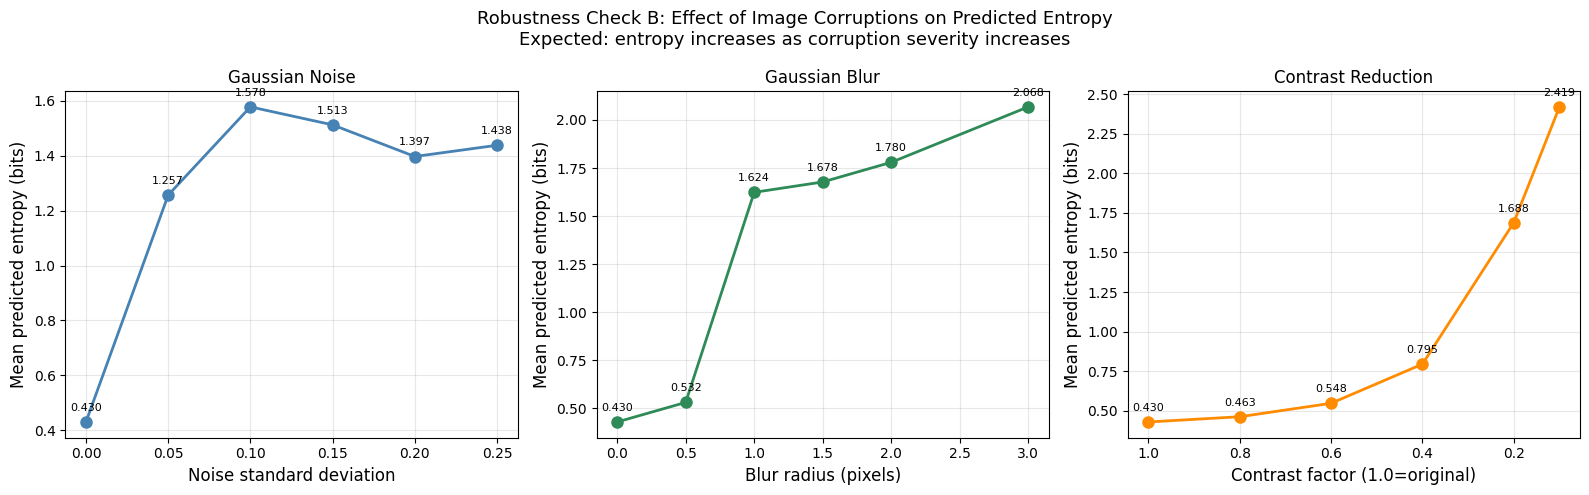

Saved to: /content/drive/MyDrive/cifar10h_project/results/explainability/robustness_corruptions.png


In [10]:
# CELL 10 — Plot corruption robustness results

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Robustness Check B: Effect of Image Corruptions on Predicted Entropy\n'
    'Expected: entropy increases as corruption severity increases',
    fontsize=13
)

#  Gaussian noise
axes[0].plot(NOISE_STDS, results_noise, 'o-',
             color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Noise standard deviation', fontsize=12)
axes[0].set_ylabel('Mean predicted entropy (bits)', fontsize=12)
axes[0].set_title('Gaussian Noise', fontsize=12)
axes[0].grid(alpha=0.3)
for x, y in zip(NOISE_STDS, results_noise):
    axes[0].annotate(f'{y:.3f}', (x, y),
                     textcoords="offset points",
                     xytext=(0, 8), ha='center', fontsize=8)

#  Gaussian blur
axes[1].plot(BLUR_RADII, results_blur, 'o-',
             color='seagreen', linewidth=2, markersize=8)
axes[1].set_xlabel('Blur radius (pixels)', fontsize=12)
axes[1].set_ylabel('Mean predicted entropy (bits)', fontsize=12)
axes[1].set_title('Gaussian Blur', fontsize=12)
axes[1].grid(alpha=0.3)
for x, y in zip(BLUR_RADII, results_blur):
    axes[1].annotate(f'{y:.3f}', (x, y),
                     textcoords="offset points",
                     xytext=(0, 8), ha='center', fontsize=8)

#  Contrast reduction
axes[2].plot(CONTRAST_VALS, results_contrast, 'o-',
             color='darkorange', linewidth=2, markersize=8)
axes[2].set_xlabel('Contrast factor (1.0=original)', fontsize=12)
axes[2].set_ylabel('Mean predicted entropy (bits)', fontsize=12)
axes[2].set_title('Contrast Reduction', fontsize=12)
axes[2].invert_xaxis()   # flip so severity increases left to right
axes[2].grid(alpha=0.3)
for x, y in zip(CONTRAST_VALS, results_contrast):
    axes[2].annotate(f'{y:.3f}', (x, y),
                     textcoords="offset points",
                     xytext=(0, 8), ha='center', fontsize=8)

plt.tight_layout()
save_path = os.path.join(EXPLAIN_DIR, 'robustness_corruptions.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

In [11]:
# CELL 11 — Final

print("NB4 COMPLETE — FILE CHECKLIST")

files_to_check = {
    "Grad-CAM low vs high entropy" : os.path.join(EXPLAIN_DIR, 'gradcam_low_vs_high_entropy.png'),
    "Failure cases Type A"         : os.path.join(EXPLAIN_DIR, 'failure_cases_type_A.png'),
    "Failure cases Type B"         : os.path.join(EXPLAIN_DIR, 'failure_cases_type_B.png'),
    "Manual inspection top-20"     : os.path.join(EXPLAIN_DIR, 'manual_inspection_top20.png'),
    "Corruption robustness plot"   : os.path.join(EXPLAIN_DIR, 'robustness_corruptions.png'),
}

all_ok = True
for name, path in files_to_check.items():
    exists = os.path.exists(path)
    size   = f"({os.path.getsize(path)/1024:.0f} KB)" if exists else ""
    print(f"  {'OK' if exists else 'MISSING':<8} {name:<35} {size}")
    if not exists:
        all_ok = False

print("\n" + "=" * 55)
if all_ok:
    print("NB4 complete. All explainability outputs saved.")

else:
    print("Some files missing — rerun the relevant cells.")
print("=" * 55)



NB4 COMPLETE — FILE CHECKLIST
  OK       Grad-CAM low vs high entropy        (341 KB)
  OK       Failure cases Type A                (77 KB)
  OK       Failure cases Type B                (74 KB)
  OK       Manual inspection top-20            (206 KB)
  OK       Corruption robustness plot          (149 KB)

NB4 complete. All explainability outputs saved.
